In [1]:
import pandas as pd
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv('C:/Python/Datasets/cookie_cats.csv')
df

,userid,version,sum_gamerounds,retention_1,retention_7
0,116,gate_30,3,False,False
1,337,gate_30,38,True,False
2,377,gate_40,165,True,False
3,483,gate_40,1,False,False
4,488,gate_40,179,True,True
...,...,...,...,...,...
90184,9999441,gate_40,97,True,False
90185,9999479,gate_40,30,False,False
90186,9999710,gate_30,28,True,False
90187,9999768,gate_40,51,True,False


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 90189 entries, 0 to 90188
Data columns (total 5 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   userid          90189 non-null  int64 
 1   version         90189 non-null  object
 2   sum_gamerounds  90189 non-null  int64 
 3   retention_1     90189 non-null  bool  
 4   retention_7     90189 non-null  bool  
dtypes: bool(2), int64(2), object(1)
memory usage: 2.2+ MB


In [4]:
df.groupby(by='userid').version.nunique().value_counts()

version
1    90189
Name: count, dtype: int64

In [5]:
df.version.value_counts()

version
gate_40    45489
gate_30    44700
Name: count, dtype: int64

<Axes: xlabel='sum_gamerounds'>

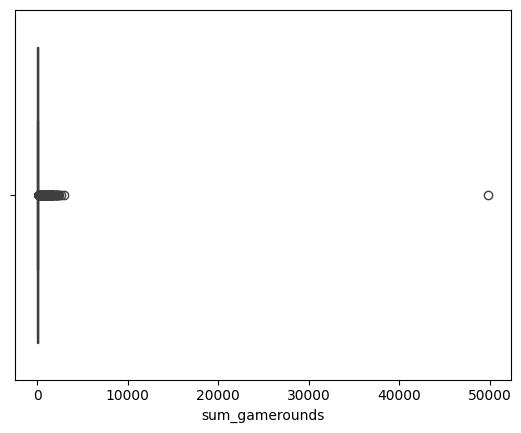

In [6]:
sns.boxplot(data=df, x='sum_gamerounds')

In [7]:
df[df.sum_gamerounds > 10000]

,userid,version,sum_gamerounds,retention_1,retention_7
57702,6390605,gate_30,49854,False,True


In [8]:
df = df[df.sum_gamerounds < 10000]

In [9]:
gate30 = df[df.version == 'gate_30']
gate40 = df[df.version == 'gate_40']

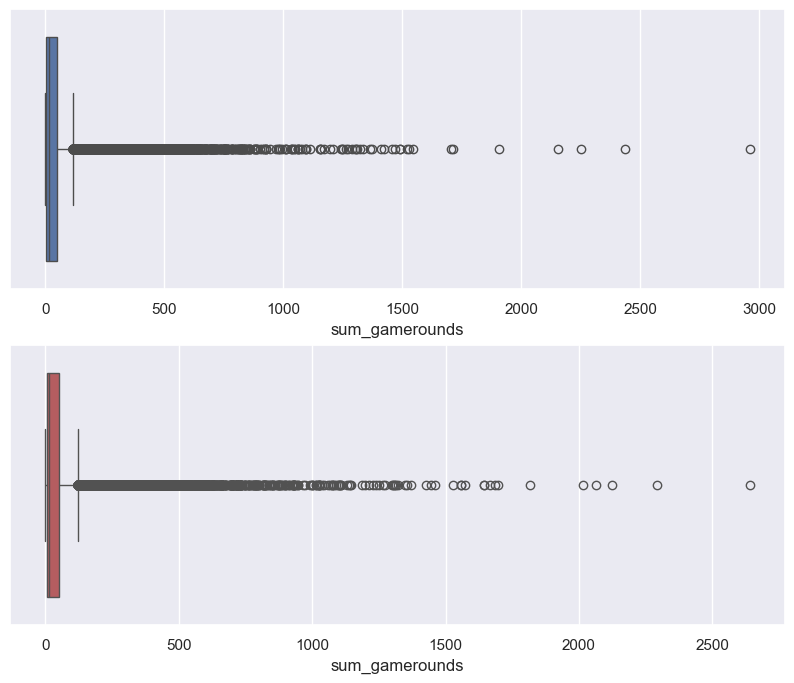

In [13]:
sns.set_theme(style='darkgrid')
fig, axes = plt.subplots(figsize=(10,8), nrows=2)
sns.boxplot(data=gate30, x='sum_gamerounds', ax = axes[0])
sns.boxplot(data=gate40, x='sum_gamerounds', ax = axes[1], color='r')
plt.show()

<Axes: xlabel='sum_gamerounds', ylabel='Count'>

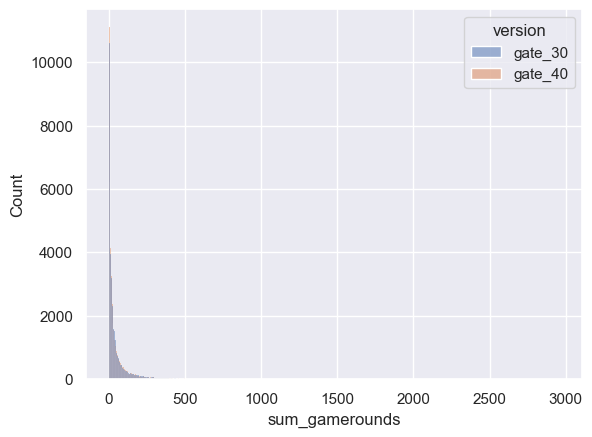

In [14]:
sns.histplot(data=df, x='sum_gamerounds', hue='version')

In [10]:
def diff_mean(sample1, sample2):
    """Вычисляет разницу средних (test - control)"""
    return np.mean(sample2) - np.mean(sample1)

In [11]:
data = (gate30.sum_gamerounds.values, gate40.sum_gamerounds.values)
data

(array([ 3, 38,  0, ..., 21, 10, 28], shape=(44699,)),
 array([165,   1, 179, ...,  30,  51,  16], shape=(45489,)))

In [ ]:
'''result = sts.bootstrap(data=data,
              statistic=diff_mean,
              n_resamples=10_000,
              random_state=42,
              method='basic')'''

In [18]:
result.confidence_interval

ConfidenceInterval(low=np.float64(-1.3405868278129947), high=np.float64(1.300259602702116))

In [19]:
result.standard_error

np.float64(0.6748923628851785)

In [20]:
result.bootstrap_distribution

array([-0.50724896, -0.1845794 , -1.00217868, ..., -1.04445431,
       -0.86153874, -0.11031822], shape=(10000,))

In [22]:
dfs = df.groupby(by='version', as_index=False).agg({'retention_1':'sum', 'retention_7':'sum', 'userid':'count', 'sum_gamerounds':'sum'})
dfs

,version,retention_1,retention_7,userid,sum_gamerounds
0,gate_30,20034,8501,44699,2294941
1,gate_40,20119,8279,45489,2333530


In [23]:
dfs['r1'] = dfs['retention_1']/dfs['userid']
dfs['r7'] = dfs['retention_7']/dfs['userid']

In [24]:
dfs

,version,retention_1,retention_7,userid,sum_gamerounds,r1,r7
0,gate_30,20034,8501,44699,2294941,0.448198,0.190183
1,gate_40,20119,8279,45489,2333530,0.442283,0.182000


In [30]:
boot_1d = []
boot_7d = []
for i in range(1000):
    boot_mean_1 = df.sample(frac=1, replace=True).groupby('version')['retention_1'].mean()
    boot_mean_7 = df.sample(frac=1, replace=True).groupby('version')['retention_7'].mean()
    boot_1d.append(boot_mean_1)
    boot_7d.append(boot_mean_7)

In [31]:
boot_1d = pd.DataFrame(boot_1d)
boot_7d = pd.DataFrame(boot_7d)

In [36]:
sns.set_theme(style='darkgrid')

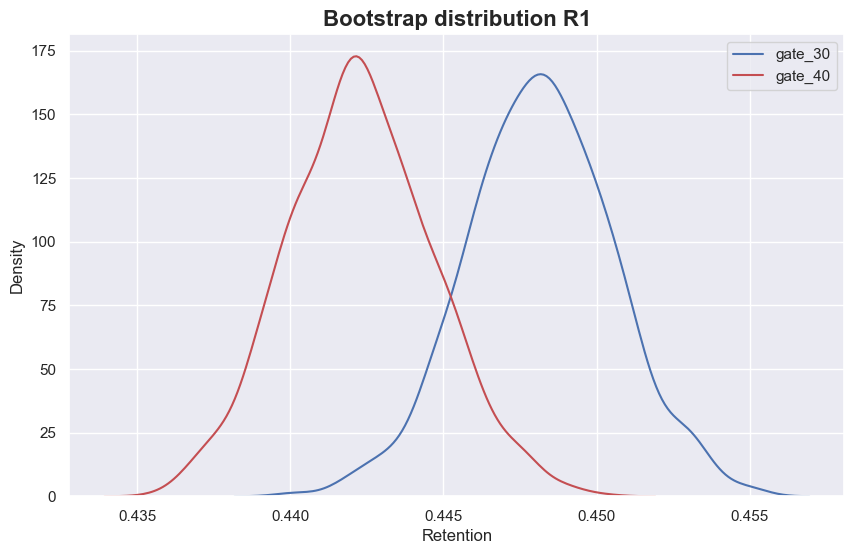

In [49]:
plt.subplots(figsize=(10,6))
sns.kdeplot(data=boot_1d, x='gate_30', label='gate_30')
sns.kdeplot(data=boot_1d, x='gate_40', color='r', label='gate_40')
plt.title('Bootstrap distribution R1', fontsize=16, fontweight='semibold')
plt.xlabel('Retention')
plt.legend()
plt.show()

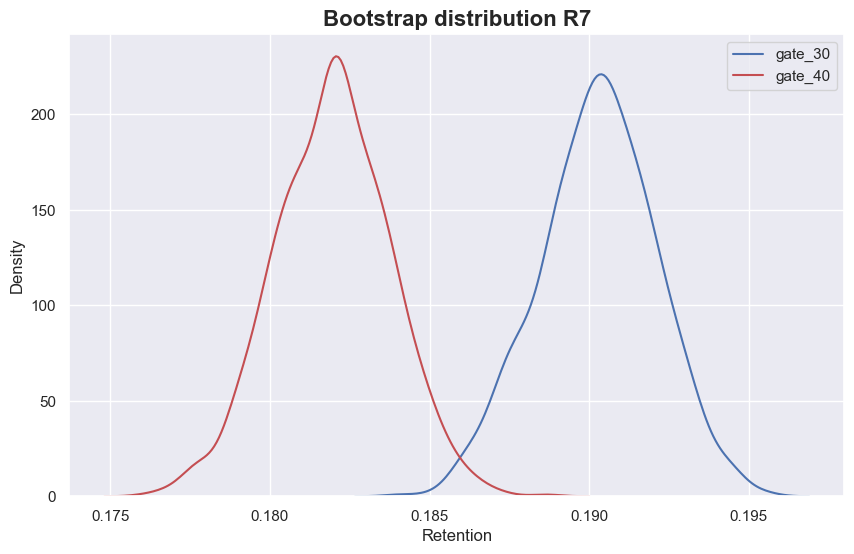

In [50]:
plt.subplots(figsize=(10,6))
sns.kdeplot(data=boot_7d, x='gate_30', label='gate_30')
sns.kdeplot(data=boot_7d, x='gate_40', color='r', label='gate_40')
plt.title('Bootstrap distribution R7', fontsize=16, fontweight='semibold')
plt.xlabel('Retention')
plt.legend()
plt.show()

In [54]:
original_means_1 = df.groupby('version')['retention_1'].mean()
original_diff_1 = original_means_1['gate_40'] - original_means_1['gate_30']

original_means_7 = df.groupby('version')['retention_7'].mean()
original_diff_7 = original_means_7['gate_40'] - original_means_7['gate_30']

In [55]:
# retention_1
boot_diffs_1 = boot_1d['gate_40'] - boot_1d['gate_30']   # Series из 1000 значений

# retention_7
boot_diffs_7 = boot_7d['gate_40'] - boot_7d['gate_30']   # Series из 1000 значений

In [58]:
p_value_1 = np.mean(np.abs(boot_diffs_1) >= np.abs(original_diff_1))
p_value_7 = np.mean(np.abs(boot_diffs_7) >= np.abs(original_diff_7))

print(f"p-value (retention_1): {p_value_1:.4f}")
print(f"p-value (retention_7): {p_value_7:.4f}")

p-value (retention_1): 0.4960
p-value (retention_7): 0.5140


In [59]:
ci_1_low = boot_diffs_1.quantile(0.025)
ci_1_high = boot_diffs_1.quantile(0.975)

ci_7_low = boot_diffs_7.quantile(0.025)
ci_7_high = boot_diffs_7.quantile(0.975)

print(f"95% CI for retention_1: [{ci_1_low:.4f}, {ci_1_high:.4f}]")
print(f"95% CI for retention_7: [{ci_7_low:.4f}, {ci_7_high:.4f}]")

95% CI for retention_1: [-0.0123, 0.0010]
95% CI for retention_7: [-0.0132, -0.0031]


In [60]:
boot_1d['diff'] = ((boot_1d['gate_30'] - boot_1d['gate_40']) / boot_1d['gate_40'] * 100)
boot_7d['diff'] = ((boot_7d['gate_30'] - boot_7d['gate_40']) / boot_7d['gate_40'] * 100)

In [61]:
# Calculating the probability that 1-day retention is greater when the gate is at level 30
prob_1 = (boot_1d['diff']>0).sum()/len(boot_1d['diff'])

# Calculating the probability that 7-days retention is greater when the gate is at level 30
prob_7 = (boot_7d['diff']>0).sum()/len(boot_7d['diff'])

# Pretty printing the probability
print(f"The probability that 1-day retention is greater when the gate is at level 30: {round(prob_1,2)*100}% \
      \nThe probability that 7-days retention is greater when the gate is at level 30: {(prob_7)*100}% ")

The probability that 1-day retention is greater when the gate is at level 30: 94.0%       
The probability that 7-days retention is greater when the gate is at level 30: 100.0% 


In [70]:
sts.mannwhitneyu(df.loc[df.version == 'gate_30', 'sum_gamerounds'], df.loc[df.version == 'gate_40', 'sum_gamerounds'])

MannwhitneyuResult(statistic=np.float64(1024285761.5), pvalue=np.float64(0.05089155279145376))